In [33]:
import os
import glob
import json
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import h5py
from vip_slap2_analysis.glutamate.summary import GlutamateSummary

import seaborn as sns

from PNW_cmap import PNW_cmap
sns.set_style('white')
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'xx-large',
         'axes.titlesize':'xx-large',
         'xtick.labelsize':'xx-large',
         'ytick.labelsize':'xx-large'}
plt.rcParams.update(params)

from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
%matplotlib notebook

In [4]:
basepath = r"\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics"
summary_path = glob.glob(os.path.join(basepath,'**summary.xlsx'))[0]
summary_df = pd.read_excel(summary_path,sheet_name='subjects')
session_df = pd.read_excel(summary_path,sheet_name='sessions')

In [5]:
target_mouse = 826033

session_paths = session_df[session_df['subject_id']==target_mouse]['session_dir'].values
summary_datapaths = [glob.glob(os.path.join(p,'**','SummaryLoCo**.mat'),recursive=True) for p in session_paths]
summary_datapaths = [x for l in summary_datapaths for x in l]
summary_datapaths

['\\\\allen\\aind\\scratch\\ophys\\Andrew\\VIP_synaptic_dynamics\\iGluSnFR4f+RCaMP3\\826033\\826033_2026-02-17_13-13-55\\826033_2026-02-17_13-13-55_slap2_2026-02-17_13-13-55\\source_extraction\\ExperimentSummary\\SummaryLoCo-260218-072719.mat',
 '\\\\allen\\aind\\scratch\\ophys\\Andrew\\VIP_synaptic_dynamics\\iGluSnFR4f+RCaMP3\\826033\\826033_2026-02-18_11-57-04\\826033_2026-02-18_11-57-04_slap2_2026-02-18_11-57-04\\source_extraction\\ExperimentSummary\\SummaryLoCo-260219-070533.mat',
 '\\\\allen\\aind\\scratch\\ophys\\Andrew\\VIP_synaptic_dynamics\\iGluSnFR4f+RCaMP3\\826033\\826033_2026-02-19_13-47-57\\826033_2026-02-19_13-47-57_slap2_2026-02-19_13-47-57\\source_extraction\\ExperimentSummary\\SummaryLoCo-260220-114728.mat',
 '\\\\allen\\aind\\scratch\\ophys\\Andrew\\VIP_synaptic_dynamics\\iGluSnFR4f+RCaMP3\\826033\\826033_2026-02-21_09-23-34\\826033_2026-02-21_09-23-34_slap2_2026-02-21_09-23-34\\source_extraction\\ExperimentSummary\\SummaryLoCo-260223-145719.mat',
 '\\\\allen\\aind\\s

In [199]:
datapath = summary_datapaths[3]

In [200]:
gs = GlutamateSummary(datapath, keep_open=True)
valid_trials_dmd1 = gs.valid_trials[0]
valid_trials_dmd2 = gs.valid_trials[1]
print(gs.n_synapses)          # list per DMD
print(gs.valid_trials[1])     # trials for DMD1

# Get dF/ls traces, all channels:
X = gs.get_traces(dmd=1, trial=valid_trials_dmd1[0], signal="dF",mode='ls', force_n_channels=2)

# X is (samples, rois, channels) OR (samples, rois) if single-channel

# Only green channel:
Xg = gs.get_traces(dmd=1, trial=valid_trials_dmd1[0], signal="dF", mode="ls", channels="green")

# User ROI traces (e.g. soma ROI):
U = gs.get_user_roi_traces(dmd=1, trial=valid_trials_dmd1[0], trace_type="F", channels=None)

# Summary image:
mean_im = gs.get_summary_image(dmd=1, image_type="meanIM")
act_im  = gs.get_summary_image(dmd=1, image_type="actIM")


[61, 50]
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 23, 24, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 60]


In [201]:
X.shape
# X[:,:,0]

(5580, 61, 2)

In [202]:
im = gs.get_summary_image(dmd=1,image_type='meanIM')[::,0,::]
im = np.nan_to_num(im, nan=0.0)

In [203]:
cl,cmap,cp = PNW_cmap.get_PNW_cmap('Sunset',n_colors=10)

<IPython.core.display.Javascript object>


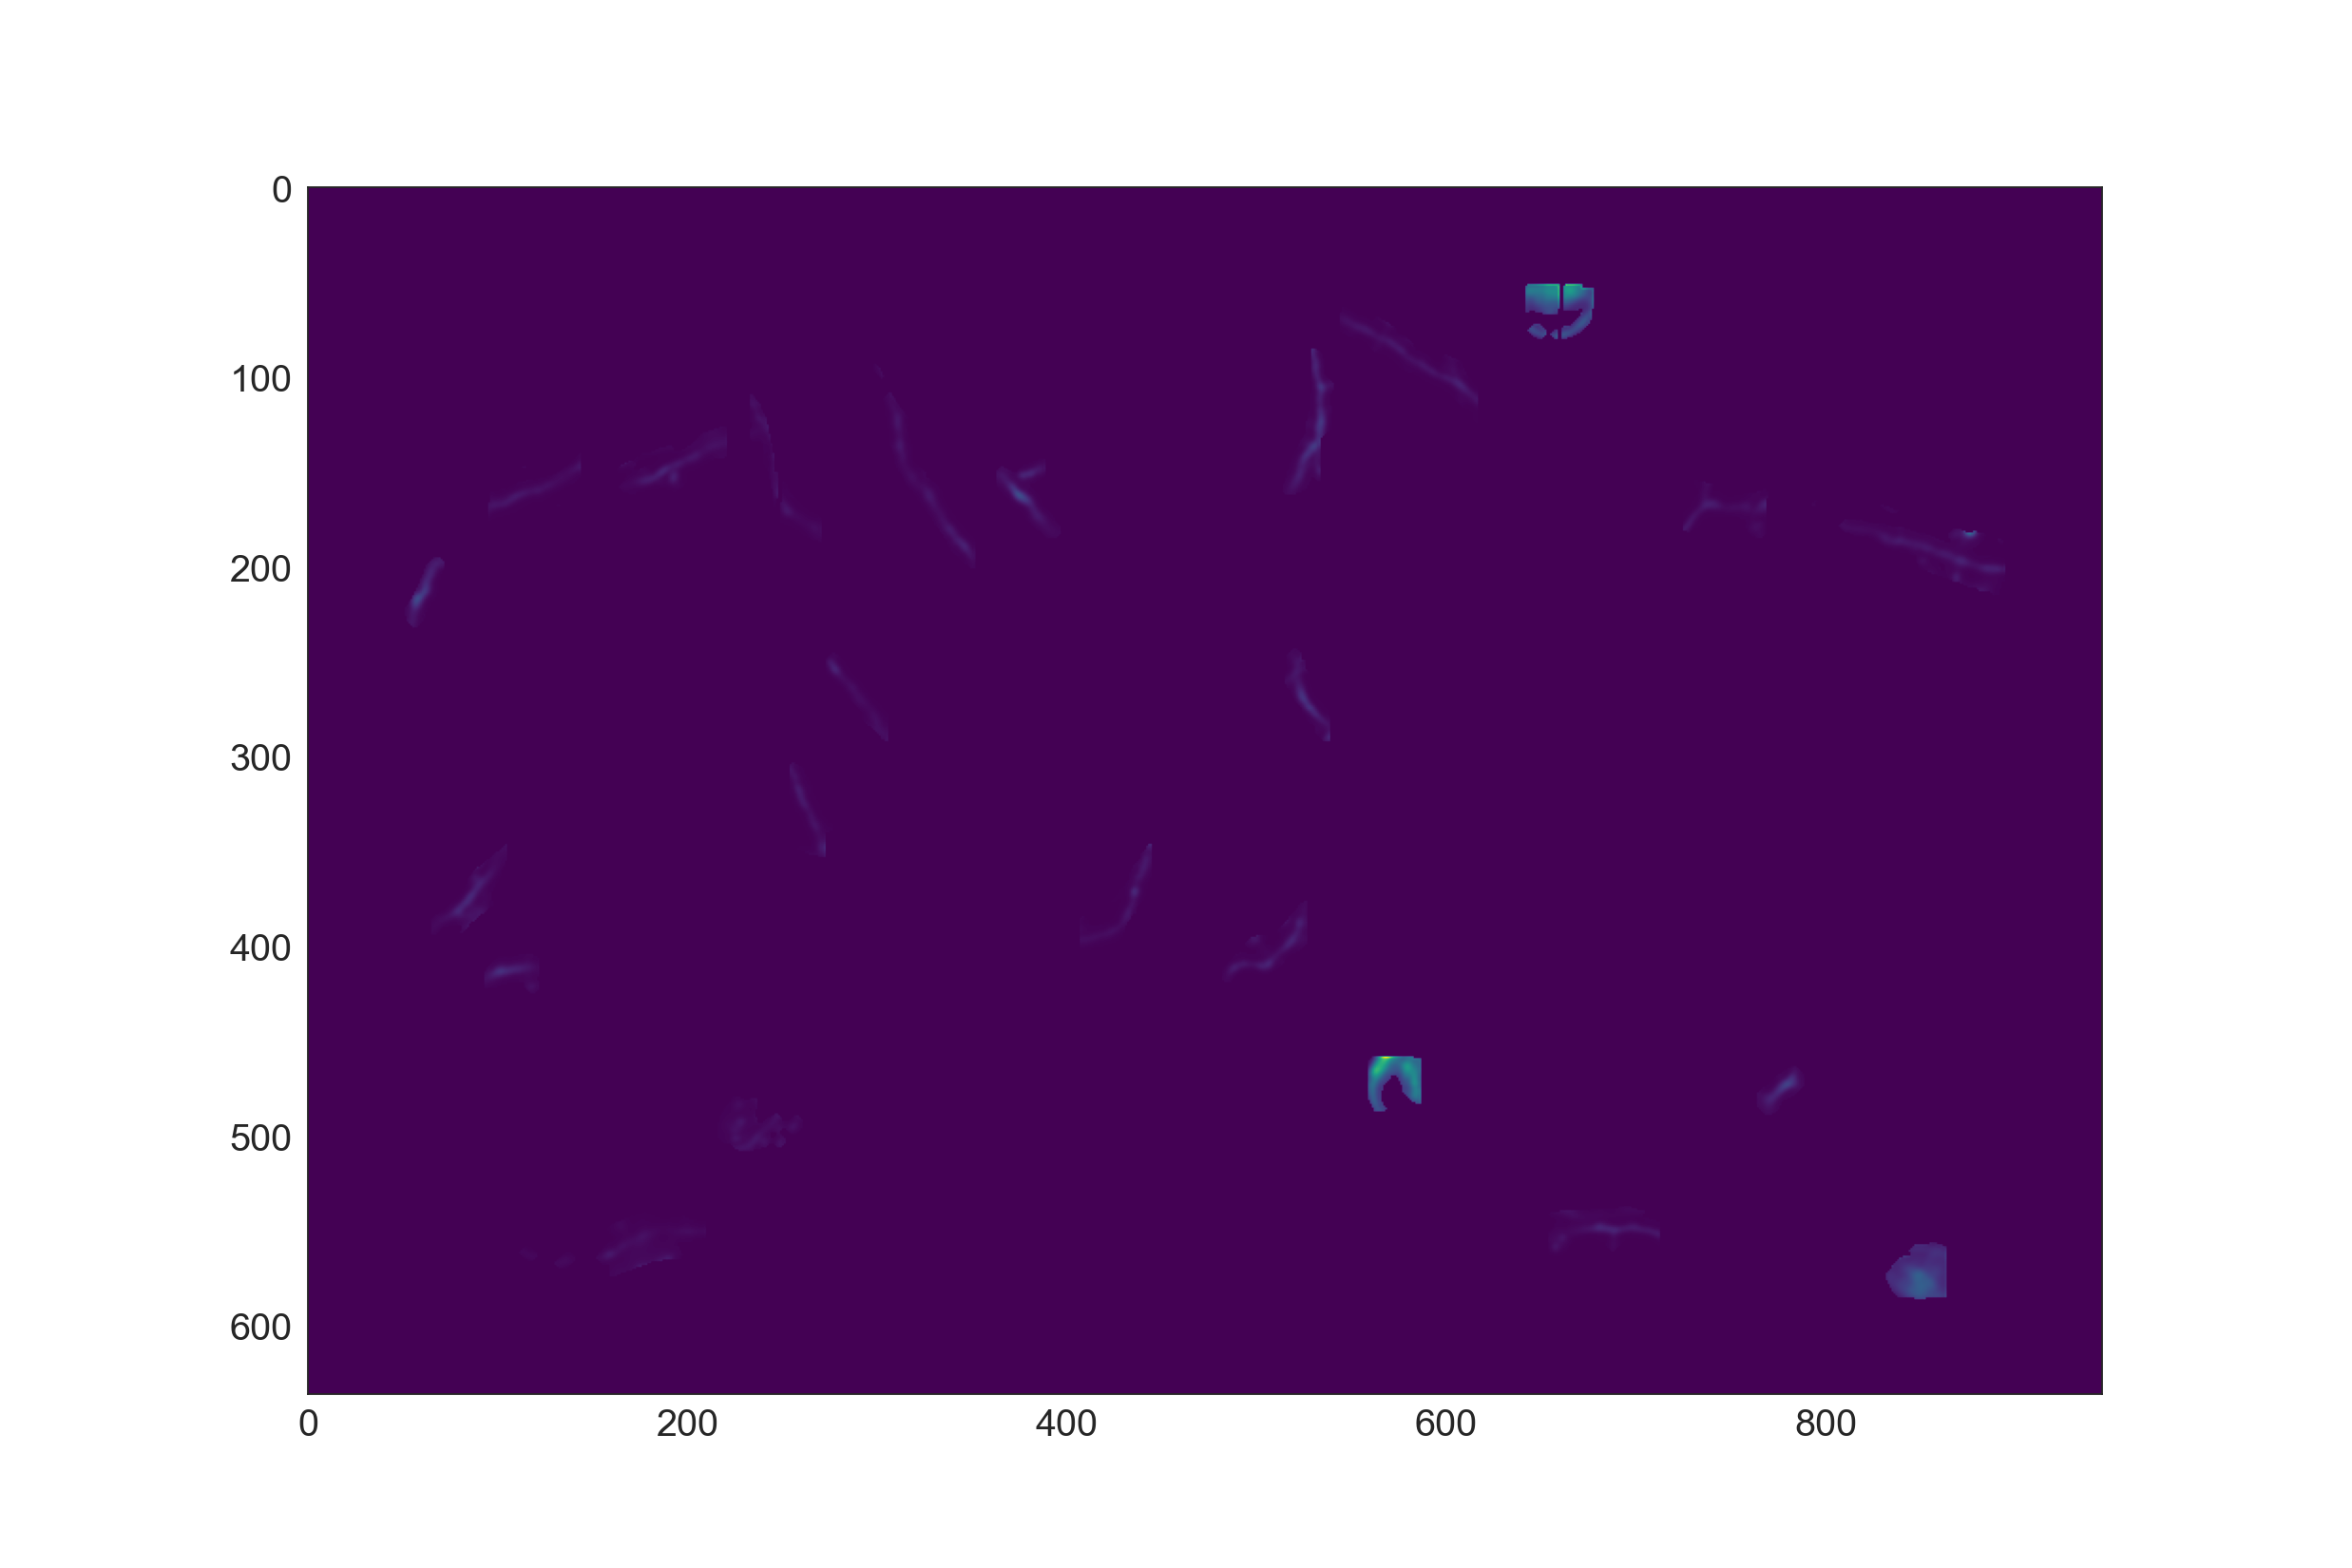

In [204]:
fig,ax=plt.subplots(figsize=(15,10))

ax.imshow(im.T,cmap='viridis')

In [205]:
valid_trials = [valid_trials_dmd1,valid_trials_dmd2]

dmd = 0

n_somas = gs.get_user_roi_traces(dmd=dmd+1,trial=valid_trials[dmd][0]).shape[0]

soma_signals = [ [] for _ in range(n_somas) ]

for trial in gs.valid_trials[dmd]:
    traces = gs.get_user_roi_traces(dmd=dmd+1,trial=trial)
    for s in range(n_somas):
        soma_signals[s].append(traces[s,1,:])    # (n_samples,)
soma_signals = [np.concatenate(chunks, axis=0) for chunks in soma_signals]

<IPython.core.display.Javascript object>


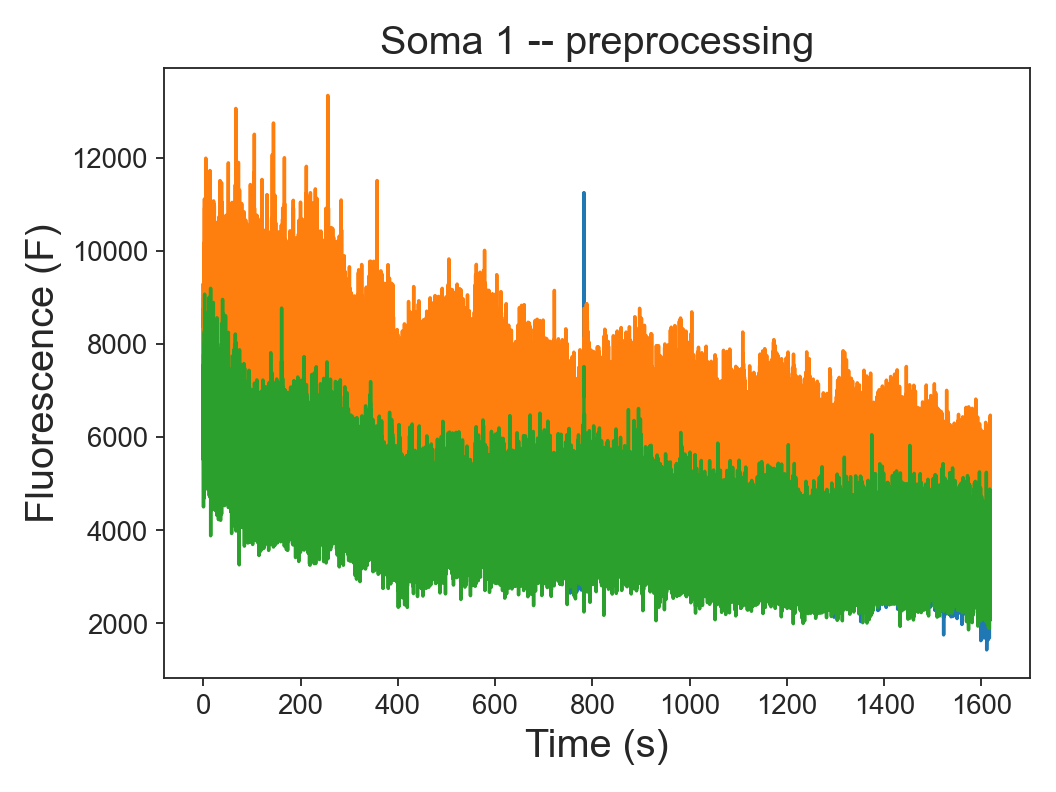

In [206]:
time = np.linspace(0,len(soma_signals[0])/200,len(soma_signals[0]))

fig,ax=plt.subplots()

ax.tick_params(axis='x',which='major',reset=True,top=False,labelsize=12)
ax.tick_params(axis='y',which='major',reset=True,right=False,labelsize=12)

for soma in soma_signals:
    ax.plot(time,soma)
ax.set_ylabel('Fluorescence (F)')
ax.set_xlabel('Time (s)')

ax.set_title('Soma 1 -- preprocessing')

fig.tight_layout()

In [213]:
out = gs.get_processed_soma_ca_all_trials(
    dmd=dmd+1,
    trace_type="Fsvd",
    fs_hz=gs.metadata["analyzeHz"],
    pad_to="max_valid",
    include_invalid=True,

    motion_correct=True,
    motion_regress_on="dF",
    motion_ridge=1e-2,
    motion_use_fields=("onlineXshift","onlineYshift","onlineZshift",
                       "motionDSr","motionDSc"
                      ),
    use_glu_as_motion_regressor=False,

    baseline_method="hull",
    denoise_window_s=2.0,   # was 1.0
    hull_window_s=90.0,     # was 30.0  (this is the big one)
    f0_floor_frac=0.05,     # was 0.02  (guardrail)

    mask_artifacts=True,
    std_factor=20.0,
    nan_pad=10,
    unmix=True,
    hp_window_s=0.5,
    ridge=1e-6,
)

In [214]:
out['dff'].shape

(61, 3, 5580)

In [215]:
# Key outputs (trial, roi, time)
dff = out["dff"]         # (n_trials, n_rois, Tpad)
ca_mc = out["ca_mc"]     # motion-regressed Ca
beta_unmix = out["beta_unmix"]

In [216]:
roi = 0
tr = 1
base = out["baseline"][tr-1, roi, :]
print("eps clamp fraction:", (base <= 1.0001e-6).mean())
print("baseline median:", np.nanmedian(base))

print("dff shape:", dff.shape)
print("fraction NaN (trial0, roi0):", (np.isnan(dff[0,0]).mean()))

eps clamp fraction: 0.0
baseline median: 14.124183439370455
dff shape: (61, 3, 5580)
fraction NaN (trial0, roi0): 0.0023297491039426525


In [217]:
# Concatenate across ALL trials (invalid trials contribute NaNs)
dff_cat = np.concatenate([dff[tr, roi, :] for tr in range(gs.n_trials)], axis=0)

print("dF/F concat len:", dff_cat.size)
print("nan frac:", np.isnan(dff_cat).mean())
print('')

baseline_cat = np.concatenate([out['baseline'][tr, roi, :] for tr in range(gs.n_trials)], axis=0)

print("baseline concat len:", baseline_cat.size)
print("nan frac:", np.isnan(baseline_cat).mean())
print('')

df_mc_r_cat = np.concatenate([out['ca_mc'][tr, roi, :] for tr in range(gs.n_trials)], axis=0)

print("mc_r concat len:", df_mc_r_cat.size)
print("nan frac:", np.isnan(df_mc_r_cat).mean())
print('')

dF/F concat len: 340380
nan frac: 0.051856748340090485

baseline concat len: 340380
nan frac: 0.051856748340090485

mc_r concat len: 340380
nan frac: 0.051856748340090485



<IPython.core.display.Javascript object>


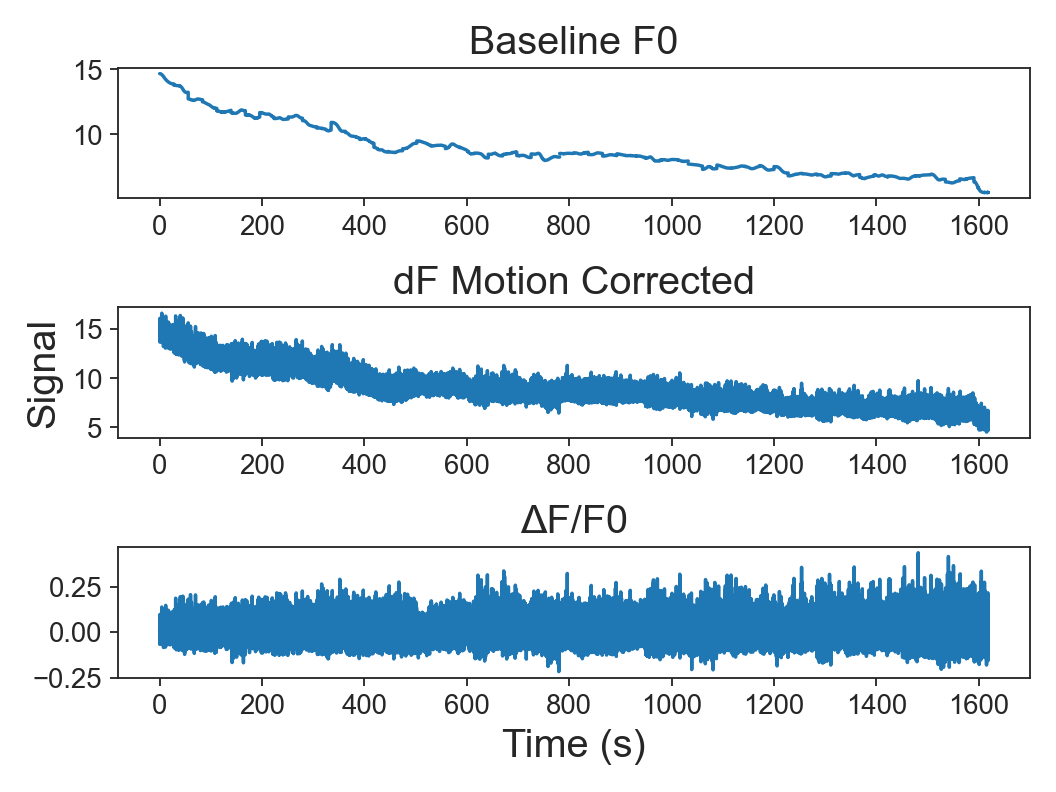

In [218]:
fig,ax = plt.subplots(3,sharex=True)

time = np.linspace(0,len(dff_cat)/200,len(dff_cat))

titles = ['Baseline F0','dF Motion Corrected','\u0394F/F0']
signals = [baseline_cat,df_mc_r_cat,dff_cat]

for i,axis in enumerate(ax.flatten()):
    axis.tick_params(axis='x',which='major',reset=True,top=False,labelsize=12)
    axis.tick_params(axis='y',which='major',reset=True,right=False,labelsize=12)
    
    axis.plot(time,signals[i])
    
    axis.set_title(titles[i])

ax[1].set_ylabel('Signal')
ax[2].set_xlabel('Time (s)')
# ax[2].set_ylim(-3,3)
fig.tight_layout()

<IPython.core.display.Javascript object>


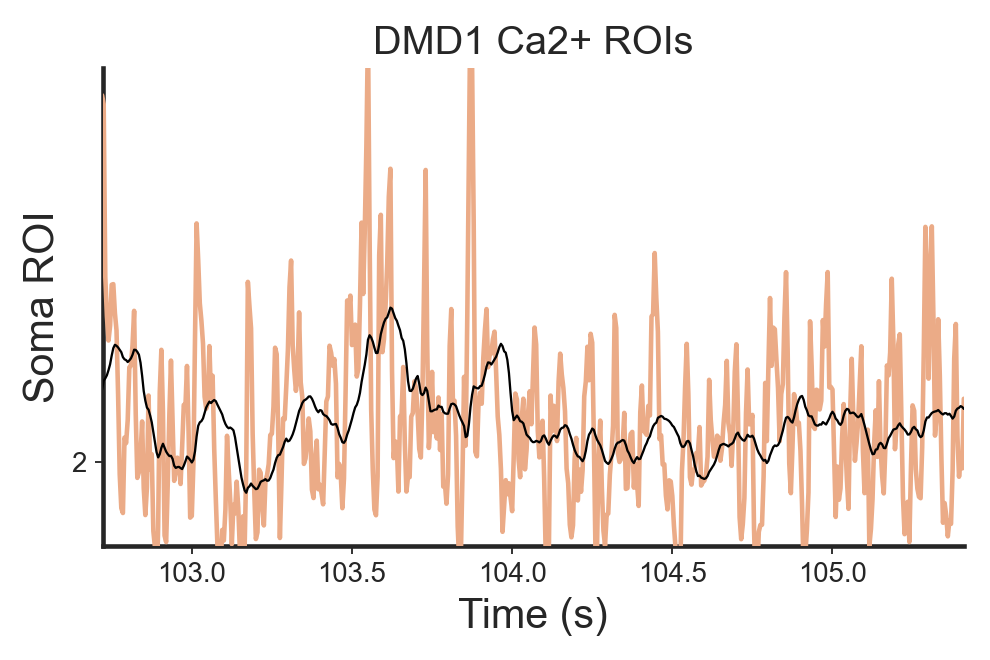

In [219]:
n_rois = np.shape(dff)[1]
offset = 0.5               # you were using i/2
fs = 200                       # Hz

cl, cmap, cp = PNW_cmap.get_PNW_cmap('Sailboat', n_colors=n_rois)

fig, ax = plt.subplots(figsize=(6, 4))
sns.despine()

ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)

tw = [0,1800]

for i in range(n_rois):
    # concatenate across trials for ROI i  -> (samples_total,)
    dff_ = np.concatenate([dff[tr, i] for tr in range(gs.n_trials)], axis=0)

    # If all NaN, skip plotting (but we’ll still label its tick below)
    if np.all(np.isnan(dff_)):
        continue

    time = np.arange(dff_.size) / fs

    y = dff_ + i * offset
    ax.plot(time[(time<=tw[1])&(time>tw[0])], y[(time<=tw[1])&(time>tw[0])], color=cp[i], zorder=10 - i,lw=2)

    y_smooth = pd.Series(y).rolling(25, min_periods=1).mean().to_numpy()
    ax.plot(time[(time<=tw[1])&(time>tw[0])], y_smooth[(time<=tw[1])&(time>tw[0])], color='k', zorder=10 - i,lw=1)

# Put ticks at the *offset positions*, labels are the ROI indices
yticks = np.arange(n_rois) * offset
ax.set_yticks(yticks)
ax.set_yticklabels(np.arange(n_rois))   # integer ROI indices, including 0

ax.set_ylabel('Soma ROI', fontsize=18)
ax.set_xlabel('Time (s)', fontsize=18)

for spine in ['left', 'bottom']:
    ax.spines[spine].set_linewidth(2)

s_bar_pad = 50    

ax.plot([tw[1]+s_bar_pad,tw[1]+s_bar_pad],[1,1.5],color='k',lw=2)
ax.text(tw[1]+s_bar_pad/5,1.0,'0.5 \u0394F/F',rotation=90)
ax.set_title(f'DMD{dmd+1} Ca2+ ROIs')
fig.tight_layout()

### Extracted glu data qc

In [34]:
glu_qc_path = Path(r"\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f\803496\2025-07-25_803496\analysis\qc\glutamate\glutamate_extraction_qc.json")
with open(glu_qc_path, "r") as f:
    glu_qc = json.load(f)
glu_qc

{'schema_version': '0.3.0',
 'session_id': '809436_2025-07-25_13-02-10',
 'summary_mat': '\\\\allen\\aind\\scratch\\ophys\\Andrew\\VIP_synaptic_dynamics\\iGluSnFR4f\\803496\\2025-07-25_803496\\803496_2025-07-25_13-02-10_slap2_2026-01-18_05-53-08\\source_extraction\\ExperimentSummary\\SummaryLoCo-260117-185357.mat',
 'bonsai_event_log_csv': '\\\\allen\\aind\\scratch\\ophys\\Andrew\\VIP_synaptic_dynamics\\iGluSnFR4f\\803496\\2025-07-25_803496\\803496_2025-07-25_13-02-10\\behavior\\VCO1_Behavior.harp\\bonsai_event_log.csv',
 'use_synapse_qc': True,
 'windows_sec': {'image': [0.25, 0.5],
  'change': [1.0, 0.75],
  'omission': [1.0, 1.5]},
 'event_counts': {'image_total': 2357,
  'image_after_epoch_filter': 2277,
  'change_total': 283,
  'change_after_epoch_filter': 274,
  'omission_total': 19,
  'omission_after_epoch_filter': 18,
  'n_unique_image_ids_total': 7,
  'n_unique_image_ids_after_epoch_filter': 7},
 'epoch_duration_sec': 1740.0180160002785,
 'per_dmd': {'DMD1': {'n_synapses_total

In [ ]:
glu_mean_path = r"\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f\803496\2025-07-25_803496\analysis\derived\glutamate\glutamate_mean_df.npz"
glu_mean = np.load(glu_mean_path,allow_pickle=True)

In [ ]:
im_names = list(glu_mean['data'][0]['DMD1']['image_identity'].keys())
colors = ['#c5cae9', '#ffcdd2', '#c8e6c9', '#ffe0b2',
 '#e1bee7', '#d7ccc8', '#cfd8dc', '#b2ebf2']

In [ ]:
dmd = 0
im = 0
syn = 12

n_pres = glu_qc['per_dmd'][f'DMD{dmd+1}']['image_count_by_id'][im_names[im]]

fig,ax=plt.subplots()

ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)

mean = glu_mean['data'][0]['DMD1']['image_identity'][im_names[im]]['mean'][syn]
std = glu_mean['data'][0]['DMD1']['image_identity'][im_names[im]]['std'][syn]/np.sqrt(n_pres)

time = np.linspace(-0.25,0.5,len(mean))
ax.plot(time,mean,color='k',lw=2)
ax.fill_between(time,mean+std,mean-std,color='lightgray',alpha=1,zorder=0)

ax.axvspan(0,0.25,alpha=0.5,zorder=1,color=colors[im])

ax.set_ylabel('\u0394F',rotation=0,labelpad=20)
ax.set_xlabel('Time (s)')

ax.set_title(f'Mean image response\nto {im_names[im]}')

fig.tight_layout()

In [ ]:
fig,ax=plt.subplots()

ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)

dmd = 0
syn = 5

n_ch = glu_qc['event_counts']['change_after_epoch_filter']

mean = glu_mean['data'][0][f'DMD{dmd+1}']['change']['mean'][syn]
std = glu_mean['data'][0][f'DMD{dmd+1}']['change']['mean'][syn]/np.sqrt(n_ch)
time = np.linspace(-1,0.75,len(mean))

ax.plot(time,mean,color='k',lw=2)
ax.fill_between(time,mean+std,mean-std,color='lightgray',alpha=1,zorder=0)

ax.axvspan(0,0.25,alpha=0.2,zorder=0)
ax.axvspan(-0.75,-0.5,alpha=0.3,zorder=0,color='lightgray')

ax.set_ylabel('\u0394F',rotation=0,labelpad=20)
ax.set_xlabel('Time (s)')

ax.set_title(f'Mean image response to image change')

fig.tight_layout()

In [ ]:
fig,ax=plt.subplots()

ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)

dmd = 0
syn = 23

n_ch = glu_qc['event_counts']['omission_after_epoch_filter']

mean = glu_mean['data'][0][f'DMD{dmd+1}']['omission']['mean'][syn]
std = glu_mean['data'][0][f'DMD{dmd+1}']['omission']['mean'][syn]/np.sqrt(n_ch)
time = np.linspace(-1,1.5,len(mean))

ax.plot(time,mean,color='k',lw=2)
ax.fill_between(time,mean+std,mean-std,color='lightgray',alpha=1,zorder=0)

ax.axvline(0,zorder=0,color='lightgray',dashes=[5,5],lw=2)
ax.axvline(0.25,zorder=0,color='lightgray',dashes=[5,5],lw=2)
ax.axvspan(-0.75,-0.5,alpha=0.3,zorder=0,color='lightgray')
ax.axvspan(0.75,1.0,alpha=0.3,zorder=0,color='lightgray')

ax.set_ylabel('\u0394F',rotation=0,labelpad=20)
ax.set_xlabel('Time (s)')

ax.set_title(f'Mean image response to image omission')

fig.tight_layout()

In [ ]:
glu_sequence_path = r"\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f\803496\2025-07-25_803496\analysis\derived\glutamate\glutamate_sequence_df.npz"
glu_sequence = np.load(glu_sequence_path,allow_pickle=True)
glu_sequence['data'][0]['DMD1']['image_identity']['stimuli\\images_A\\imk01378.tiff']['repeated']['mean'].shape

In [ ]:
glu_sequence['data'][0]['DMD1']['image_identity'].keys()

In [ ]:
traces = glu_sequence['data'][0]['DMD2']['image_identity'][ 'stimuli\\images_A\\imk00459.tiff']['repeated']['mean'].transpose(1,0,2)

shape = traces.shape[1:]
concat_traces = [trace.reshape(shape[0]*shape[1]) for trace in traces]

In [ ]:
fig,ax=plt.subplots()

mean = np.mean(concat_traces,axis=0)
time = np.linspace(0,len(mean)/200,len(mean))
ax.plot(time,mean)

ax.set_xlabel('Time sec (s)')

fs = 200
flash_start = 50 / fs      # 0.25 s
flash_dur = 50 / fs        # 0.25 s
gray_dur = 100 / fs        # 0.5 s
cycle_dur = flash_dur + gray_dur

n_flashes = shape[0]  # change as needed

for i in range(n_flashes):
    start = flash_start + i * cycle_dur
    end = start + flash_dur
    ax.axvspan(start, end, alpha=0.2)

fig.tight_layout()

In [ ]:
glu_single_path = r"\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f\803496\2025-07-25_803496\analysis\derived\glutamate\glutamate_single_trial_df.npz"
glu_single = np.load(glu_single_path,allow_pickle=True)
for im in glu_single['data'][0]['DMD1']['image_identity'].keys():
    print(im)
    print(glu_single['data'][0]['DMD1']['image_identity'][im].shape)

In [ ]:
bonsai_csv = r"\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f\803496\2025-07-25_803496\803496_2025-07-25_13-02-10\behavior\VCO1_Behavior.harp\bonsai_event_log.csv"
stim_df = pd.read_csv(bonsai_csv)

time_col = "corrected_timestamp" if "corrected_timestamp" in stim_df.columns else "corrected_timestamps"

vals = stim_df["Value"].astype(str)

# exclude non-stimulus rows explicitly
is_image = vals.str.lower().str.endswith((".tif", ".tiff"))
is_photodiode = vals.str.contains("photodiode", case=False, na=False)

image_df = stim_df.loc[is_image & ~is_photodiode, ["Value", time_col]].copy()
image_df = image_df.rename(columns={time_col: "onset_time"})
image_df.head()

In [ ]:
bonsai_counts = image_df["Value"].value_counts().sort_index()
bonsai_counts

In [ ]:
extracted_counts = {}
for image_id, arr in glu_single['data'][0]["DMD1"]["image_identity"].items():
    extracted_counts[image_id] = arr.shape[0]

extracted_counts = pd.Series(extracted_counts).sort_index()
comparison = pd.DataFrame({
    "bonsai_total": bonsai_counts,
    "extracted_dmd1": extracted_counts,
})
comparison["difference"] = comparison["bonsai_total"] - comparison["extracted_dmd1"]
comparison

### Extracted Ca2+ QC

In [177]:
ca_mean_path = r"\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\826033\826033_2026-02-21_09-23-34\analysis\derived\calcium\calcium_mean_dff.npz"
ca_mean = np.load(ca_mean_path,allow_pickle=True)

In [178]:
ca_mean['data'][0]['DMD1']

{'image_identity': {'stimuli\\images_A\\imk00459.tiff': {'mean': array([[ 2.34115573e-03,  2.48062628e-03, -1.20172660e-03,
           -2.50806601e-03, -2.87842660e-03, -5.56227278e-03,
           -4.13350551e-03, -4.60578132e-03, -1.88069956e-03,
           -1.62864926e-03, -2.90891704e-03, -3.00378606e-03,
           -5.06631142e-04,  2.78818380e-03,  1.94689550e-03,
            3.99152160e-04,  1.37782840e-03,  2.74490615e-03,
            4.32215981e-03,  1.36310514e-03, -2.47406325e-04,
           -1.71758832e-03, -9.59014805e-04, -7.00004795e-04,
           -8.71757665e-04, -1.68087593e-03, -2.10248054e-03,
           -1.31661679e-03, -5.03462232e-03, -3.87947134e-03,
           -2.82652287e-03, -2.14326869e-03, -1.98983756e-04,
            3.32951670e-04,  1.97272080e-03,  1.43888698e-03,
           -4.41000728e-05, -1.24830884e-03,  3.80740481e-04,
            1.67954089e-03, -3.86248955e-04, -3.87772930e-04,
           -1.69839707e-03, -9.09947639e-05,  1.09301743e-03,
        

In [179]:
ca_qc_path = Path(r"\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f+RCaMP3\826033\826033_2026-02-21_09-23-34\analysis\qc\calcium\calcium_extraction_meta.json")
with open(ca_qc_path, "r") as f:
    ca_qc = json.load(f)
ca_qc

{'schema_version': '0.1.0',
 'session_id': '826033_2026-02-21_09-23-34',
 'indicator2': 'RCaMP3',
 'motion_correct': True,
 'use_soma_qc': True,
 'windows_sec': {'image': [0.25, 0.5],
  'change': [1.0, 0.75],
  'omission': [1.0, 1.5]},
 'event_counts': {'image_total': 2363,
  'image_after_epoch_filter': 2357,
  'change_total': 265,
  'change_after_epoch_filter': 264,
  'omission_total': 32,
  'omission_after_epoch_filter': 32,
  'n_unique_image_ids_total': 7,
  'n_unique_image_ids_after_epoch_filter': 7},
 'epoch_duration_sec': 1800.7265279998537,
 'per_dmd': {'DMD1': {'n_rois_total': 3,
   'n_rois_kept': 3,
   'n_trials_total': 61,
   'n_trials_valid': 58,
   'n_trials_invalid': 3,
   'trial_lengths_samples': [5580,
    5580,
    5580,
    5580,
    5580,
    5580,
    5580,
    5580,
    5580,
    5580,
    5580,
    5580,
    5580,
    5580,
    5580,
    5580,
    5580,
    5580,
    5580,
    5580,
    5580,
    5580,
    5580,
    5580,
    5580,
    5580,
    5580,
    5580,
   

In [180]:
im_names = list(ca_mean['data'][0]['DMD1']['image_identity'].keys())
colors = ['#c5cae9', '#ffcdd2', '#c8e6c9', '#ffe0b2',
 '#e1bee7', '#d7ccc8', '#cfd8dc', '#b2ebf2']

<IPython.core.display.Javascript object>


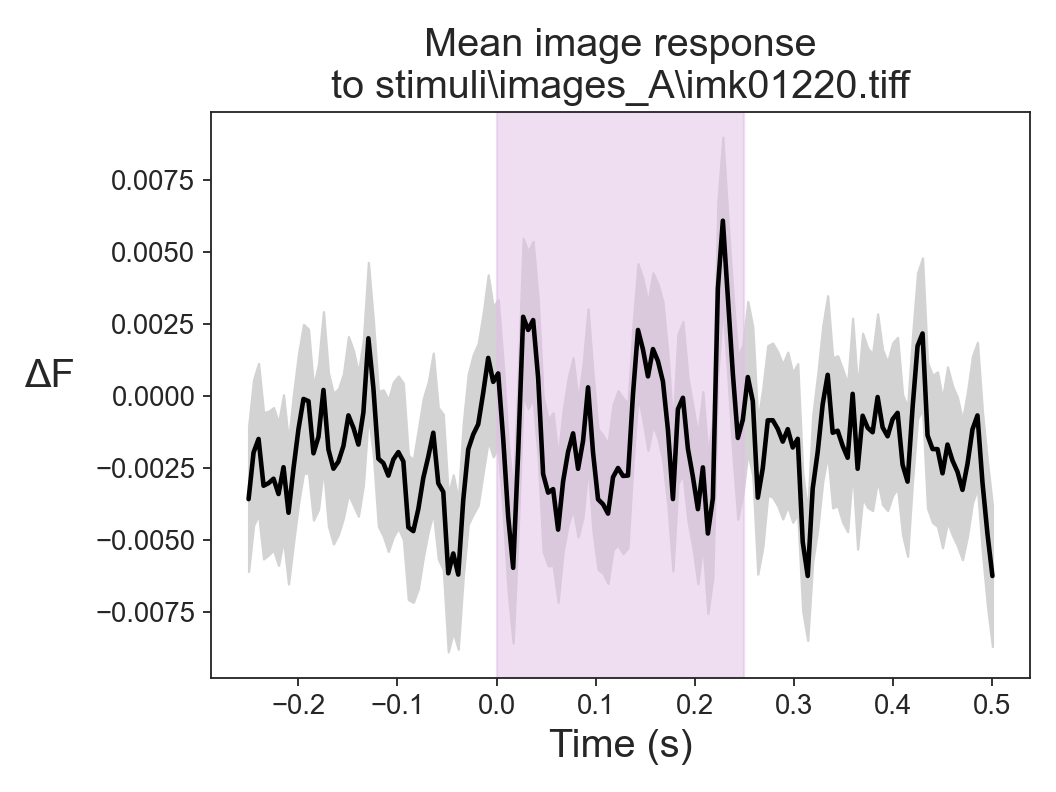

In [198]:
dmd = 0
im = 4
syn = 1

n_pres = ca_qc['per_dmd'][f'DMD{dmd+1}']['image_count_by_id'][im_names[im]]

fig,ax=plt.subplots()

ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)

mean = ca_mean['data'][0][f'DMD{dmd+1}']['image_identity'][im_names[im]]['mean'][syn]
std = ca_mean['data'][0][f'DMD{dmd+1}']['image_identity'][im_names[im]]['std'][syn]/np.sqrt(n_pres)

time = np.linspace(-0.25,0.5,len(mean))
ax.plot(time,mean,color='k',lw=2)
ax.fill_between(time,mean+std,mean-std,color='lightgray',alpha=1,zorder=0)

ax.axvspan(0,0.25,alpha=0.5,zorder=1,color=colors[im])

ax.set_ylabel('\u0394F',rotation=0,labelpad=20)
ax.set_xlabel('Time (s)')

ax.set_title(f'Mean image response\nto {im_names[im]}')

fig.tight_layout()

In [ ]:
fig,ax=plt.subplots()

ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)

dmd = 1
syn = 1

n_ch = glu_qc['event_counts']['change_after_epoch_filter']

mean = ca_mean['data'][0][f'DMD{dmd+1}']['change']['mean'][syn]
std = ca_mean['data'][0][f'DMD{dmd+1}']['change']['mean'][syn]/np.sqrt(n_ch)
time = np.linspace(-1,0.75,len(mean))

ax.plot(time,mean,color='k',lw=2)
ax.fill_between(time,mean+std,mean-std,color='lightgray',alpha=1,zorder=0)

ax.axvspan(0,0.25,alpha=0.2,zorder=0)
ax.axvspan(-0.75,-0.5,alpha=0.3,zorder=0,color='lightgray')

ax.set_ylabel('\u0394F',rotation=0,labelpad=20)
ax.set_xlabel('Time (s)')

ax.set_title(f'Mean image response to image change')

fig.tight_layout()

In [ ]:
fig,ax=plt.subplots()

ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)

dmd = 1
syn = 0

n_ch = glu_qc['event_counts']['omission_after_epoch_filter']

mean = ca_mean['data'][0][f'DMD{dmd+1}']['omission']['mean'][syn]
std = ca_mean['data'][0][f'DMD{dmd+1}']['omission']['mean'][syn]/np.sqrt(n_ch)
time = np.linspace(-1,1.5,len(mean))

ax.plot(time,mean,color='k',lw=2)
ax.fill_between(time,mean+std,mean-std,color='lightgray',alpha=1,zorder=0)

ax.axvline(0,zorder=0,color='lightgray',dashes=[5,5],lw=2)
ax.axvline(0.25,zorder=0,color='lightgray',dashes=[5,5],lw=2)
ax.axvspan(-0.75,-0.5,alpha=0.3,zorder=0,color='lightgray')
ax.axvspan(0.75,1.0,alpha=0.3,zorder=0,color='lightgray')

ax.set_ylabel('\u0394F',rotation=0,labelpad=20)
ax.set_xlabel('Time (s)')

ax.set_title(f'Mean image response to image omission')

fig.tight_layout()